In [1]:
from vkt.core import Crossing, StrandRef,connect, disconnect
from vkt.core import parse_gauss_code, VirtualLink, VirtualLinkDiagram
from vkt.core.arc_routing_strandref import route_arc_from_strandref


In [2]:
gauss_code = "O1-O2-U1-U2-"
crossings = parse_gauss_code(gauss_code)
link = VirtualLink(crossings)

In [3]:
link.crossings

[Crossing(id=0, kind=classical, sign=-1),
 Crossing(id=1, kind=classical, sign=-1)]

In [4]:
link_diagram=link.to_diagram()

In [5]:
link_diagram.crossings

[Crossing(id=0, kind=classical, sign=-1),
 Crossing(id=1, kind=classical, sign=-1)]

In [ ]:
#link_diagram.admit_virtual_crossing(link_diagram.crossings[0].ref(0),link_diagram.crossings[0].ref(1),1,0)

Crossing(id=2, kind=virtual, sign=None)

In [6]:
link_diagram.crossings

[Crossing(id=0, kind=classical, sign=-1),
 Crossing(id=1, kind=classical, sign=-1)]

In [7]:
 link_diagram.components()

[[StrandRef(crossing=0, strand=0),
  StrandRef(crossing=1, strand=0),
  StrandRef(crossing=0, strand=1),
  StrandRef(crossing=1, strand=1)]]

In [8]:
route_arc_from_strandref(link_diagram.crossings[0].ref(0))

([0, 4, 4], [1, 1, 3])

In [9]:
route_arc_from_strandref(link_diagram.crossings[0].ref(1))

([1, 3, 3], [0, 0, 4])

In [10]:
route_arc_from_strandref(link_diagram.crossings[1].ref(0))

([4, -1, -1], [5, 5, 0])

In [11]:
route_arc_from_strandref(link_diagram.crossings[1].ref(1))

([5, 5, -2, -2, 0], [4, 6, 6, -1, -1])

In [2]:
gc = 'O1-U2-O3+U1-O4-U5-O6-U3+O2-U4-O5-U6-'
crossings = parse_gauss_code(gc)
link = VirtualLink(crossings)
link_diagram= VirtualLinkDiagram(link)

In [3]:
link_diagram.compute_arc_routes()

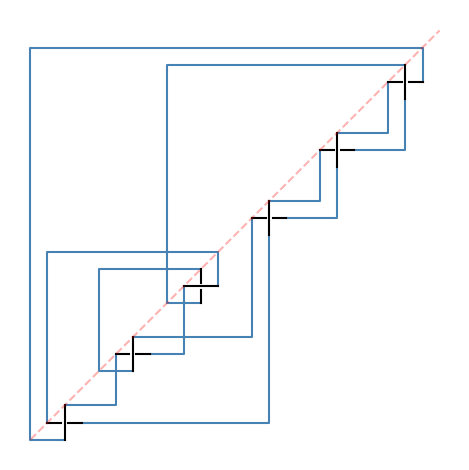

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

all_vals = []

# Plot arcs
for crossing in link.crossings:
    for i in range(2):
        result = route_arc_from_strandref(crossing.ref(i))
        if result is None:
            continue
        xs, ys = result
        all_vals.extend(xs)
        all_vals.extend(ys)
        ax.plot(xs, ys, color='steelblue')

# Plot crossings
for n, crossing in enumerate(link.crossings):
    cx, cy = 4 * n, 4 * n
    if crossing.sign == 1:  # positive: x-axis over, y-axis broken
        ax.plot([cx - 1, cx + 1], [cy, cy], color='black')
        ax.plot([cx, cx], [cy - 1, cy - 0.2], color='black')
        ax.plot([cx, cx], [cy + 0.2, cy + 1], color='black')
    else:  # negative: y-axis over, x-axis broken
        ax.plot([cx, cx], [cy - 1, cy + 1], color='black')
        ax.plot([cx - 1, cx - 0.2], [cy, cy], color='black')
        ax.plot([cx + 0.2, cx + 1], [cy, cy], color='black')

lim = [min(all_vals), max(all_vals)]
ax.plot(lim, [v + 1 for v in lim], color='red', linestyle='--', alpha = .3)

ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

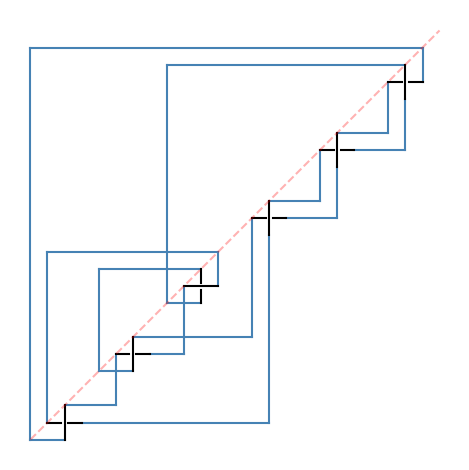

<Axes: >

In [4]:
link_diagram.plot()

In [22]:
link_diagram.arc_routes[link_diagram.crossings[0].ref(0).next()]

KeyError: StrandRef(crossing=12, strand=1)

In [1]:
from vkt.core import Crossing, StrandRef,connect, disconnect
from vkt.core import parse_gauss_code, VirtualLink, VirtualLinkDiagram
from vkt.core.arc_routing_strandref import route_arc_from_strandref
from vkt.core.seifert_nesting import seifert_nesting

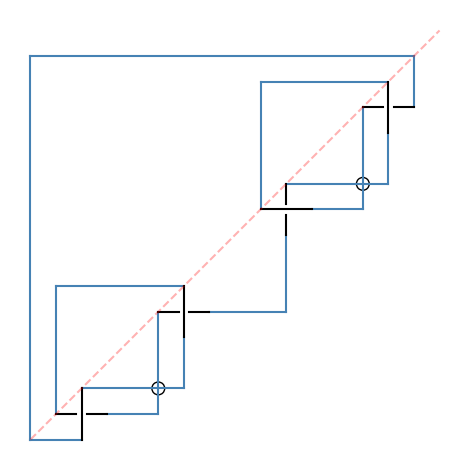

6
1
3


In [2]:
gc = 'O1-O2-U1-U2-U3+O4-O3+U4-'
crossings = parse_gauss_code(gc)
link = VirtualLink(crossings)
link_diagram = VirtualLinkDiagram(link)
#link_diagram.compute_arc_routes()
link_diagram.plot()
print(len(link_diagram.crossings))
print(len(link_diagram.components()))
print(len(link_diagram.seifert_components()))

In [3]:
seifert_nesting(link_diagram)

  Component 0 corner: (0, 1), y - x = 1
  Component 0 corner: (4, 1), y - x = -3
  Component 0 corner: (4, 1), y - x = -3
  Component 0 corner: (4, 3), y - x = -1
  Component 0 corner: (4, 5), y - x = 1
  Component 0 corner: (-1, 5), y - x = 6
  Component 0 corner: (-1, 5), y - x = 6
  Component 0 corner: (-1, 0), y - x = 1
  Component 0 corner: (0, 1), y - x = 1
  Component 0 corner: (4, 1), y - x = -3
  Component 0 corner: (4, 1), y - x = -3
  Component 0 corner: (4, 3), y - x = -1
  Component 0 corner: (4, 5), y - x = 1
  Component 0 corner: (-1, 5), y - x = 6
  Component 0 corner: (-1, 5), y - x = 6
  Component 0 corner: (-1, 0), y - x = 1
  Component 0 corner: (0, 1), y - x = 1
  Component 0 corner: (4, 1), y - x = -3
  Component 0 corner: (4, 1), y - x = -3
  Component 0 corner: (4, 3), y - x = -1
  Component 0 corner: (4, 5), y - x = 1
  Component 0 corner: (-1, 5), y - x = 6
  Component 0 corner: (-1, 5), y - x = 6
  Component 0 corner: (-1, 0), y - x = 1
  Component 0 corner: 

([], [])

In [4]:
for seg in all_segments:
    for pt in [seg.start, seg.end]:
        x, y = pt
        print(f"  Component {i} corner: ({x}, {y}), y - x = {y - x}")

NameError: name 'all_segments' is not defined

In [4]:
for i, circle in enumerate(link_diagram.seifert_components()):
    print(f"Component {i}:")
    for ref in circle:
        if ref in link_diagram.arc_routes:
            for seg in link_diagram.arc_routes[ref]:
                print(f"  {seg.start} -> {seg.end}")

Component 0:
  (0, 1) -> (4, 1)
  (4, 1) -> (4, 3)
  (5, 4) -> (8, 4)
  (8, 4) -> (8, 7)
  (4, 5) -> (-1, 5)
  (-1, 5) -> (-1, 0)
  (1, 0) -> (3, 0)
  (3, 0) -> (3, 4)
Component 1:
  (1, 0) -> (3, 0)
  (3, 0) -> (3, 4)
  (4, 5) -> (-1, 5)
  (-1, 5) -> (-1, 0)
  (5, 4) -> (8, 4)
  (8, 4) -> (8, 7)
  (8, 9) -> (12, 9)
  (12, 9) -> (12, 11)
  (9, 8) -> (11, 8)
  (11, 8) -> (11, 12)
  (12, 13) -> (7, 13)
  (7, 13) -> (7, 8)
  (13, 12) -> (13, 14)
  (13, 14) -> (-2, 14)
  (-2, 14) -> (-2, -1)
  (-2, -1) -> (0, -1)
  (0, 1) -> (4, 1)
  (4, 1) -> (4, 3)
Component 2:
  (8, 9) -> (12, 9)
  (12, 9) -> (12, 11)
  (13, 12) -> (13, 14)
  (13, 14) -> (-2, 14)
  (-2, 14) -> (-2, -1)
  (-2, -1) -> (0, -1)
  (12, 13) -> (7, 13)
  (7, 13) -> (7, 8)
  (9, 8) -> (11, 8)
  (11, 8) -> (11, 12)


In [5]:
link_diagram.seifert_components()

[[StrandRef(crossing=0, strand=0),
  StrandRef(crossing=4, strand=1),
  StrandRef(crossing=4, strand=0),
  StrandRef(crossing=1, strand=1),
  StrandRef(crossing=1, strand=0),
  StrandRef(crossing=0, strand=1)],
 [StrandRef(crossing=0, strand=1),
  StrandRef(crossing=4, strand=0),
  StrandRef(crossing=4, strand=1),
  StrandRef(crossing=1, strand=0),
  StrandRef(crossing=1, strand=1),
  StrandRef(crossing=2, strand=0),
  StrandRef(crossing=2, strand=1),
  StrandRef(crossing=5, strand=0),
  StrandRef(crossing=5, strand=1),
  StrandRef(crossing=3, strand=0),
  StrandRef(crossing=3, strand=1),
  StrandRef(crossing=0, strand=0)],
 [StrandRef(crossing=2, strand=0),
  StrandRef(crossing=5, strand=1),
  StrandRef(crossing=5, strand=0),
  StrandRef(crossing=3, strand=1),
  StrandRef(crossing=3, strand=0),
  StrandRef(crossing=2, strand=1)]]